In [ ]:
# NumPy: Matematiksel işlemler ve dizi manipülasyonu için
import numpy as np

# Pandas: Veri analizi ve manipülasyonu için
import pandas as pd

# Matplotlib: Görselleştirme için
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# OpenCV: Görüntü işleme için
import cv2

# Scikit-learn: Veri ön işleme ve metrikler için
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow ve Keras: Derin öğrenme modelleri için
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50

# Ultralytics: YOLO modeli için
# Terminal'de çalıştırınız: pip install ultralytics
# from ultralytics import YOLO

# Diğer önemli kütüphaneler
import warnings
import os
from pathlib import Path
import time

# Uyarıları gizle
warnings.filterwarnings('ignore')

# GPU kullanımını kontrol et
print(f"GPU Kullanılabilir: {tf.config.list_physical_devices('GPU')}")
print(f"TensorFlow Sürümü: {tf.__version__}")

GPU Kullanılabilir: []
TensorFlow Sürümü: 2.20.0


**VERİ SETİ YÜKLEME VE KEŞFETME**

In [ ]:

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Eğitim veri seti şekli: {x_train.shape}")
print(f"Eğitim etiketleri şekli: {y_train.shape}")
print(f"Test veri seti şekli: {x_test.shape}")
print(f"Test etiketleri şekli: {y_test.shape}")

class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f"Sınıf Sayısı: {len(np.unique(y_train))}")
print(f"Sınıflar: {class_names}")



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Eğitim veri seti şekli: (60000, 28, 28)
Eğitim etiketleri şekli: (60000,)
Test veri seti şekli: (10000, 28, 28)
Test etiketleri şekli: (10000,)
Sınıf Sayısı: 10
Sınıflar: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


**VERİ SETİ GÖRSELLEŞTİRME**

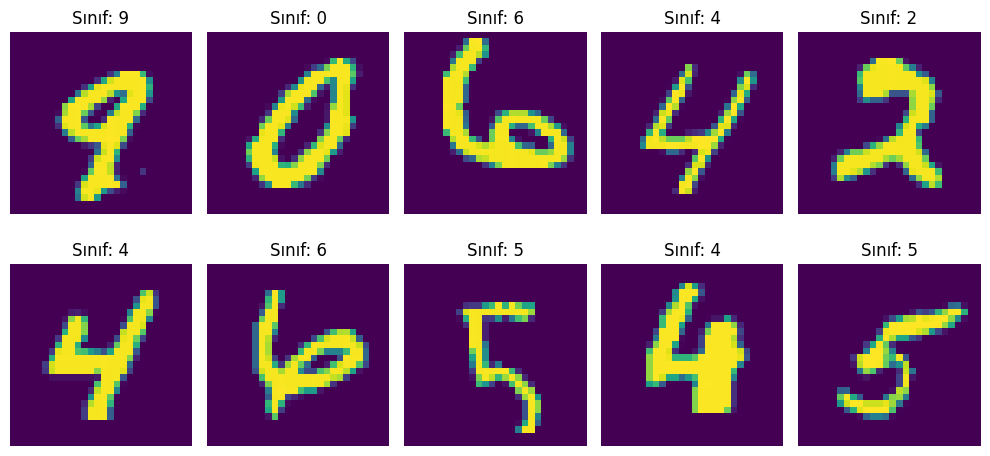

Örnek görüntüler yukarıda gösterilmektedir. 


In [ ]:

fig, axes = plt.subplots(2,5,figsize=(10,5))
axes = axes.ravel()

#10 adet rastgele index seçilir
random_indices = np.random.choice(len(x_train), 10, replace=False)

for idx, ax in enumerate(axes):
  #Rastgele indexlerden görüntü alınır
  image = x_train[random_indices[idx]]
  label = y_train[random_indices[idx]]

  ax.imshow(image.astype('uint8')) #Görüntü ekrana eklenir

  ax.set_title(f"Sınıf: {class_names[label]}") #Başlığa sınıd adı yazılır
  ax.axis('off')

plt.tight_layout()
plt.show()

print("Örnek görüntüler yukarıda gösterilmektedir. ")


**VERİ ÖN İŞLEME**

In [ ]:

#Görüntü piksel değelreri 0-255'ten 0-1 arasına ölçeklendirildi, bu şekilde daha ızlı ve stabil eğitilebilir
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

#Etiketler one-hot kodlamasına dönüştürülür
num_classes = len(class_names)
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print(f"Normalize edilen eğitim verisi (min/max): {x_train_normalized.min():.2f} / {x_train_normalized.max():.2f}")
print(f"One Hot kodlanmış etiket örneği: {y_train_categorical[0]}")
print(f"One Hot kodlanmış etiket şekli: {y_train_categorical.shape}")

Normalize edilen eğitim verisi (min/max): 0.00 / 1.00
One Hot kodlanmış etiket örneği: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
One Hot kodlanmış etiket şekli: (60000, 10)


**VERİ AGUMENTASYON**

In [ ]:

#ImageDataGenerator, eğitim sırasında görüntüleri işler
#overfitting azalır model daha iyi genelleme yapar

train_datagen = ImageDataGenerator(
    rotation_range=20,        # ±20 derece döndür
    width_shift_range=0.2,    # Genişlik için ±20% kaydır
    height_shift_range=0.2,   # Yükseklik için ±20% kaydır
    horizontal_flip=True,     # %50 ihtimalle yatay çevir
    zoom_range=0.2,           # 0.8-1.2x arasında yakınlaş
    fill_mode='nearest'       # Boş pikselleri en yakın değerle doldur
)

# Test verisi için augmentasyon yapma (sadece normalize et)
test_datagen = ImageDataGenerator()

print("Veri Augmentasyon başarıyla tanımlandı.")

Veri Augmentasyon başarıyla tanımlandı.


**CNN MODELİ OLUŞTURMA**

In [ ]:

# Sequential modeli oluştur (katmanlar sırayla eklenecek)
model_cnn = models.Sequential([
    # İlk Convolutional Blok
    # 32 filtre, 3x3 çekirdek, ReLU aktivasyon, input şekli 32x32x3
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),  # Batch Normalization - eğitimi hızlandırır
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # 2x2 pencerelerle maksimum pooling - boyutu 16x16 yapar
    layers.Dropout(0.25),  # %25 dropout - overfitting'i önler

    # İkinci Convolutional Blok
    # 64 filtre, output: 8x8x64
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # Boyutu 8x8 yapar
    layers.Dropout(0.25),

    # Üçüncü Convolutional Blok
    # 128 filtre, output: 4x4x128
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),  # Boyutu 4x4 yapar
    layers.Dropout(0.25),

    # Fully Connected Katmanlar
    # 4x4x128 = 2048 düğümü düzleştir
    layers.Flatten(),

    # 256 nöronlu Dense katman, ReLU aktivasyon
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),  # %50 dropout - yüksek kapasiteyi düşür

    # 10 sınıf için output katmanı, softmax aktivasyon
    layers.Dense(num_classes, activation='softmax')
])

# Model mimarisini göster
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

**MODEL DERLEME VE EĞİTİMİ**

In [ ]:

# Modeli açıkça derlemeden önce yapılandırılır
# input_shape, batch boyutunu (None) içermelidir
model_cnn.build(input_shape=(None, 32, 32, 3))

model_cnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
print("Model derlendi.")

Model derlendi.


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,  # 5 epoch
    restore_best_weights=True  #En iyi olanları geri yükle
)

#ReduceLROnPlateau,cvalidation_loss iyileşmezse öğrenme oranını azaltır
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  #Öğrenme oranını 0.5 ile çarp
    patience=3,  #3 epoch
    min_lr=1e-7  #Minimum öğrenme oranı
)

#Modeli eğit
print("Model eğitimi başlıyor...")
start_time = time.time()

x_train_processed = np.expand_dims(x_train_normalized, axis=-1)

# 2. Görüntüleri 32x32 boyutuna yeniden boyutlandır
x_train_processed = tf.image.resize(x_train_processed, [32, 32]).numpy()

# 3. Grayscale (tek kanal) görüntüleri 3 kanallı (RGB) formata dönüştür
x_train_processed = tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_train_processed)).numpy()

#fit() yerine fit() = veri augmentasyonu için
history = model_cnn.fit(
    x_train_processed, y_train_categorical,  # x_train_normalized yerine x_train_processed kullanıldı
    batch_size=128,  #Her adımda 128 örnek
    epochs=30,  #Maksimum 30 epoch (
    validation_split=0.2,  #%20'sini validation için ayrılır
    callbacks=[early_stopping, reduce_lr],
    verbose=1  # Her epoch'u yazdır
)

training_time = time.time() - start_time
print(f"\nEğitim süresi: {training_time:.2f} saniye")

Model eğitimi başlıyor...
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 482s 1s/step - accuracy: 0.9335 - loss: 0.2153 - val_accuracy: 0.9265 - val_loss: 0.2436 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 388s 1s/step - accuracy: 0.9804 - loss: 0.0632 - val_accuracy: 0.9844 - val_loss: 0.0557 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 441s 1s/step - accuracy: 0.9852 - loss: 0.0474 - val_accuracy: 0.9891 - val_loss: 0.0350 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 464s 1s/step - accuracy: 0.9881 - loss: 0.0373 - val_accuracy: 0.9923 - val_loss: 0.0316 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 390s 1s/step - accuracy: 0.9892 - loss: 0.0334 - val_accuracy: 0.9849 - val_loss: 0.0460 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 458s 1s/step - accuracy: 0.9905 - loss: 0.0286 - val_accuracy: 0.9906 - val_loss: 0.0320 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - a

**EĞİTİM SONUÇLARINI GÖRSELLEŞTİRME**

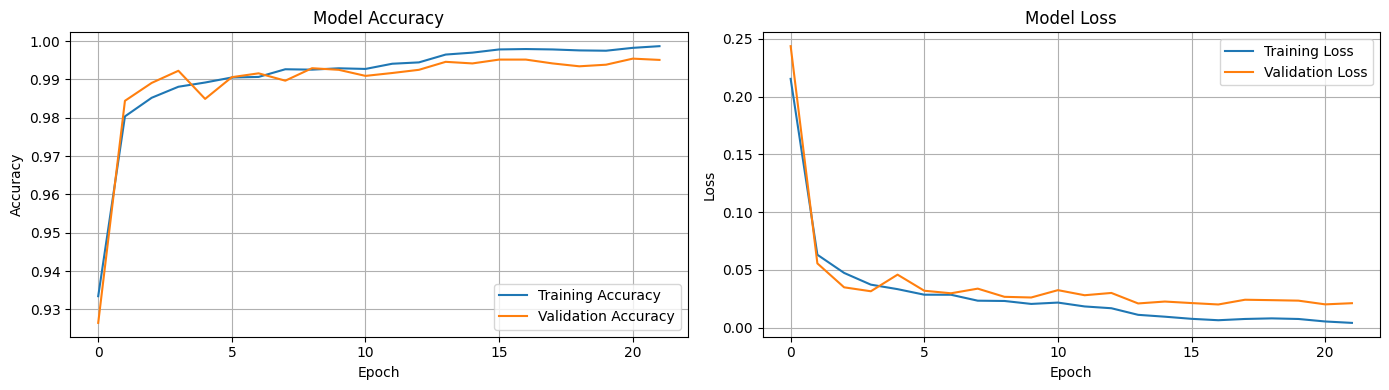


Final Training Accuracy: 0.9987
Final Validation Accuracy: 0.9951


In [ ]:

# Eğitim geçmişinden accuracy ve loss değerlerini al
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy grafik
# Training accuracy (mavi): Eğitim seti üzerindeki performans
# Validation accuracy (turuncu): Validation seti üzerindeki performans
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss grafik
# Training loss (mavi): Eğitim seti üzerindeki kayıp
# Validation loss (turuncu): Validation seti üzerindeki kayıp
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Son epoch'daki sonuçları yazdır
final_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_accuracy:.4f}")
print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")

**TEST SETİ İLE DEĞERLENDİRME**

In [ ]:
# Test seti üzerinde modeli değerlendir

# Hata düzeltme: x_test_normalized verisinin modelin beklediği input_shape=(32, 32, 3) ile uyumlu hale getirilmesi
# MNIST görüntüleri (28, 28) boyutunda ve tek kanallıdır.
# 1. Tek kanal ekle: (10000, 28, 28) -> (10000, 28, 28, 1)
x_test_processed = np.expand_dims(x_test_normalized, axis=-1)

# 2. Görüntüleri 32x32 boyutuna yeniden boyutlandır
x_test_processed = tf.image.resize(x_test_processed, [32, 32]).numpy()

# 3. Grayscale (tek kanal) görüntüleri 3 kanallı (RGB) formata dönüştür
x_test_processed = tf.image.grayscale_to_rgb(tf.convert_to_tensor(x_test_processed)).numpy()

test_loss, test_accuracy = model_cnn.evaluate(x_test_processed, y_test_categorical, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Set Başarısı: {test_accuracy*100:.2f}%")

Test Loss: 0.0168
Test Accuracy: 0.9958
Test Set Başarısı: 99.58%


**MODEL TAHMİNLERİ VE SONUÇLAR**

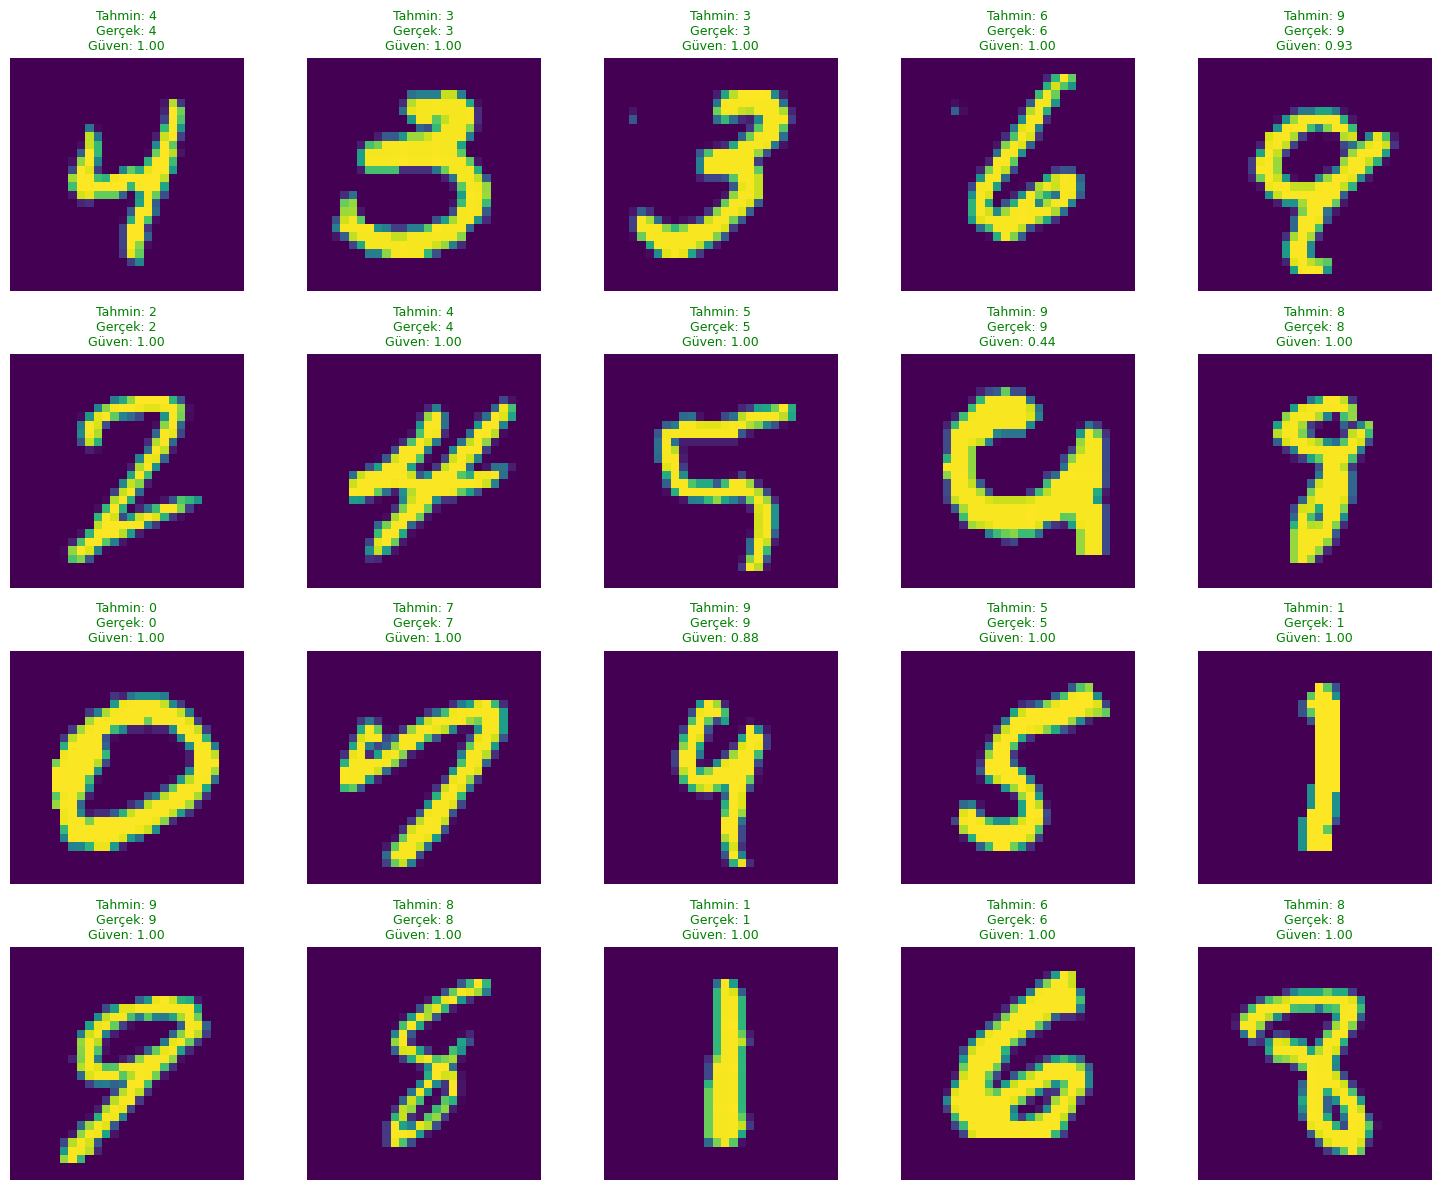

In [ ]:
#MODEL TAHMİNLERİ VE SONUÇLAR

# Test seti üzerinde tahmin yap
# predict(): Her sınıf için probability değeri döndürür
y_pred_probs = model_cnn.predict(x_test_processed, verbose=0)

# Maksimum probability'ye sahip sınıfı seç
y_pred = np.argmax(y_pred_probs, axis=1)

# 20 rastgele test örneği seç ve sonuçları göster
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

random_indices = np.random.choice(len(x_test), 20, replace=False)

for idx, ax in enumerate(axes):
    image = x_test[random_indices[idx]]
    true_label = y_test[random_indices[idx]]
    pred_label = y_pred[random_indices[idx]]
    confidence = y_pred_probs[random_indices[idx]][pred_label]

    # Görüntüyü göster
    ax.imshow(image.astype('uint8'))

    # Tahmin doğruysa yeşil, yanlışsa kırmızı başlık
    color = 'green' if true_label == pred_label else 'red'
    title = f"Tahmin: {class_names[pred_label]}\n"
    title += f"Gerçek: {class_names[true_label]}\n"
    title += f"Güven: {confidence:.2f}"

    ax.set_title(title, color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

**CONFUSSION MATRIX VE SINIFLANDIRMA RAPORU**

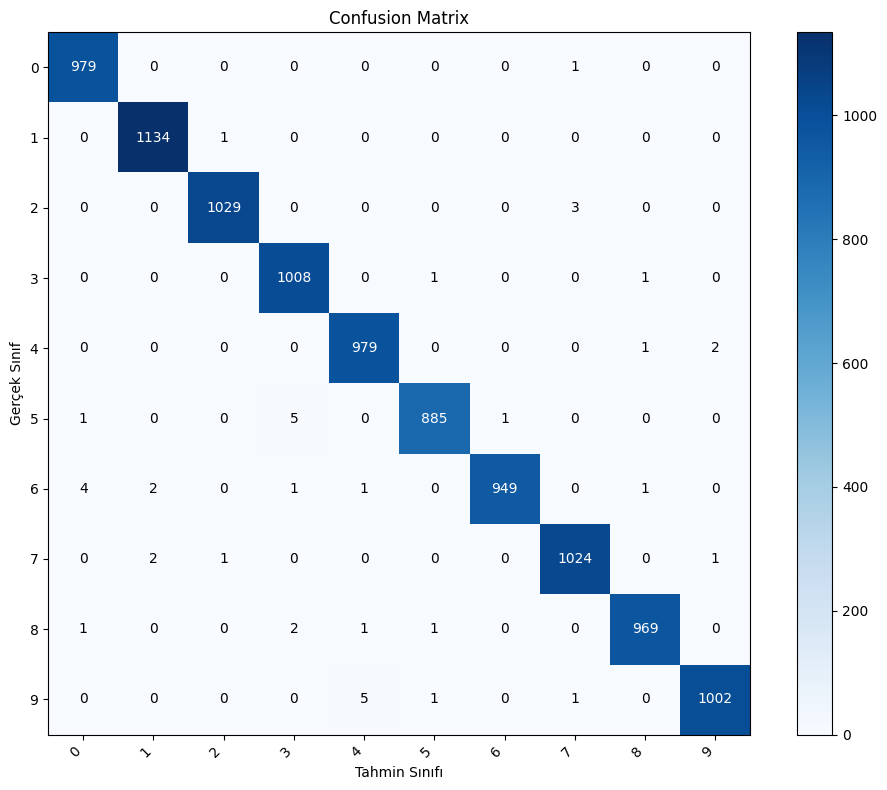

In [ ]:

# Confusion Matrix: Her sınıf için tahmin matrisini gösterir
cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix'i görselleştir
plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()

# Eksen etiketlerini ayarla
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

# Değerleri matriks üzerine yaz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Sınıfı')
plt.tight_layout()
plt.show()

In [ ]:
# Sınıflandırma Raporu: Precision, Recall, F1-Score metrikleri
# Precision: Tahmin edilen pozitif örneklerin kaçı doğru
# Recall: Gerçek pozitif örneklerin kaçı bulundu
# F1-Score: Precision ve Recall'ın harmonik ortalaması
report = classification_report(y_test, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      0.99       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       1.00      1.00      1.00      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      1.00      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



**TRANSFER LEARNING - MobileNetV2 İLE CNN **

In [ ]:

# ImageNet verisi ile önceden eğitilmiş MobileNetV2 yükle
# include_top=False: Classification katmanını hariç tut, sadece feature extraction
base_model = MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

# Base model'in katmanlarını freeze et (eğitim sırasında ağırlıkları değiştirme)
# Bu, ImageNet'ten öğrenilen özellikleri korur
base_model.trainable = False

# Transfer Learning modeli oluştur
model_transfer = models.Sequential([
    # Önceden eğitilmiş MobileNetV2
    base_model,

    # Global Average Pooling: Spatial boyutu (H, W) kaldır, C boyutunu koru
    layers.GlobalAveragePooling2D(),

    # Dense layer: 256 nöron
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    # Output layer: 10 sınıf
    layers.Dense(num_classes, activation='softmax')
])

# Model mimarisini göster
model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Transfer Learning modeli derle

# Modeli açıkça derlemeden önce yapılandırın
# input_shape, batch boyutunu (None) içermelidir
# model_transfer.build(input_shape=(None, 32, 32, 3)) # Redundant and causes error

model_transfer.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer Learning modeli derlendi.")

Transfer Learning modeli derlendi.


In [ ]:
# Transfer Learning modeli eğit (çok daha az epoch gerekir)
print("Transfer Learning modeli eğitiliyor...")
start_time = time.time()

history_transfer = model_transfer.fit(
    x_train_processed, y_train_categorical, # x_train_normalized yerine x_train_processed kullanıldı
    batch_size=128,
    epochs=15,  # Daha az epoch yeterli
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

training_time_transfer = time.time() - start_time
print(f"\nTransfer Learning eğitim süresi: {training_time_transfer:.2f} saniye")

Transfer Learning modeli eğitiliyor...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.6473 - loss: 1.0367 - val_accuracy: 0.6826 - val_loss: 0.9500 - learning_rate: 5.0000e-04
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 80s 118ms/step - accuracy: 0.6622 - loss: 0.9926 - val_accuracy: 0.6909 - val_loss: 0.9213 - learning_rate: 5.0000e-04
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.6698 - loss: 0.9695 - val_accuracy: 0.6973 - val_loss: 0.9036 - learning_rate: 5.0000e-04
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 120ms/step - accuracy: 0.6760 - loss: 0.9508 - val_accuracy: 0.6988 - val_loss: 0.8933 - learning_rate: 2.5000e-04
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.6800 - loss: 0.9428 - val_accuracy: 0.7007 - val_loss: 0.8855 - learning_rate: 2.5000e-04

Transfer Learning eğitim süresi: 266.10 saniye


In [ ]:
# Transfer Learning modeli test et
test_loss_transfer, test_accuracy_transfer = model_transfer.evaluate(x_test_processed, y_test_categorical, verbose=0)

print(f"Transfer Learning Test Accuracy: {test_accuracy_transfer:.4f}")
print(f"Transfer Learning Test Set Başarısı: {test_accuracy_transfer*100:.2f}%")

# Modelleri karşılaştır
print(f"\n--- Model Karşılaştırması ---")
print(f"CNN Model Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Transfer Learning Test Accuracy: {test_accuracy_transfer:.4f} ({test_accuracy_transfer*100:.2f}%)")
print(f"Transfer Learning Avantajı: {(test_accuracy_transfer - test_accuracy)*100:.2f}%")

Transfer Learning Test Accuracy: 0.6725
Transfer Learning Test Set Başarısı: 67.25%

--- Model Karşılaştırması ---
CNN Model Test Accuracy: 0.9958 (99.58%)
Transfer Learning Test Accuracy: 0.6725 (67.25%)
Transfer Learning Avantajı: -32.33%
